# Age Estimation based on Human Voice

<br>
Play an audio file.

In [4]:
!kaggle datasets download -d mozillaorg/common-voice


Dataset URL: https://www.kaggle.com/datasets/mozillaorg/common-voice
License(s): CC0-1.0
100% 12.0G/12.0G [02:38<00:00, 195MB/s]
100% 12.0G/12.0G [02:38<00:00, 81.5MB/s]


In [72]:
from IPython.display import Audio, display

# Use the correct path format
audio_path = 'cv_corpus_v1/cv-valid-train/cv-valid-train/sample-000000.mp3'

# Display the audio widget
display(Audio(audio_path))


In [73]:
from IPython.display import Audio, display

def play_sound(audio_path):
    """
    Function to play audio using IPython display.

    Parameters:
    audio_path (str): The path to the audio file (supports mp3, wav, etc.).
    """
    # Display the audio widget
    display(Audio(audio_path))

# Example usage:
audio_path = 'cv_corpus_v1/cv-valid-train/cv-valid-train/sample-000000.mp3'
play_sound(audio_path)


In [5]:
!unzip common-voice.zip


Streaming output truncated to the last 5000 lines.
  inflating: cv-valid-train/cv-valid-train/sample-190776.mp3  
  inflating: cv-valid-train/cv-valid-train/sample-190777.mp3  
  inflating: cv-valid-train/cv-valid-train/sample-190778.mp3  
  inflating: cv-valid-train/cv-valid-train/sample-190779.mp3  
  inflating: cv-valid-train/cv-valid-train/sample-190780.mp3  
  inflating: cv-valid-train/cv-valid-train/sample-190781.mp3  
  inflating: cv-valid-train/cv-valid-train/sample-190782.mp3  
  inflating: cv-valid-train/cv-valid-train/sample-190783.mp3  
  inflating: cv-valid-train/cv-valid-train/sample-190784.mp3  
  inflating: cv-valid-train/cv-valid-train/sample-190785.mp3  
  inflating: cv-valid-train/cv-valid-train/sample-190786.mp3  
  inflating: cv-valid-train/cv-valid-train/sample-190787.mp3  
  inflating: cv-valid-train/cv-valid-train/sample-190788.mp3  
  inflating: cv-valid-train/cv-valid-train/sample-190789.mp3  
  inflating: cv-valid-train/cv-valid-train/sample-190790.mp3  
  in

In [6]:
!mkdir -p cv_corpus_v1
!mv cv-invalid cv-other-dev cv-other-test cv-other-train cv-valid-dev cv-valid-test cv-valid-train cv_corpus_v1/
!mv *.csv cv_corpus_v1/


In [7]:
import subprocess
from os import listdir
from os.path import isfile, join
import os

# Directories that contain MP3 files
dirs = ["cv-invalid", "cv-other-dev", "cv-other-test", "cv-other-train", "cv-valid-dev", "cv-valid-test", "cv-valid-train"]

# Loop through the directories
for dir in dirs:
    print(f"Processing directory: {dir}")

    # Check for nested folders and list the files
    nested_folder = join("cv_corpus_v1", dir, dir)  # Handles the extra nesting

    if os.path.exists(nested_folder):
        for file in listdir(nested_folder):
            if isfile(join(nested_folder, file)):
                # Create the wav-files directory if it doesn't exist
                wav_dir = join("cv_corpus_v1", "wav-files", dir)
                if not os.path.exists(wav_dir):
                    os.makedirs(wav_dir)

                # Convert MP3 to WAV using ffmpeg
                mp3_file = join(nested_folder, file)
                wav_file = join(wav_dir, "{}.wav".format(file[:-4]))

                print(f"Converting {mp3_file} to {wav_file}")
                subprocess.call(['ffmpeg', '-i', mp3_file, wav_file])
    else:
        print(f"Directory {nested_folder} not found!")


Streaming output truncated to the last 5000 lines.
Converting cv_corpus_v1/cv-invalid/cv-invalid/sample-003194.mp3 to cv_corpus_v1/wav-files/cv-invalid/sample-003194.wav
Converting cv_corpus_v1/cv-invalid/cv-invalid/sample-015155.mp3 to cv_corpus_v1/wav-files/cv-invalid/sample-015155.wav
Converting cv_corpus_v1/cv-invalid/cv-invalid/sample-006871.mp3 to cv_corpus_v1/wav-files/cv-invalid/sample-006871.wav
Converting cv_corpus_v1/cv-invalid/cv-invalid/sample-012367.mp3 to cv_corpus_v1/wav-files/cv-invalid/sample-012367.wav
Converting cv_corpus_v1/cv-invalid/cv-invalid/sample-005743.mp3 to cv_corpus_v1/wav-files/cv-invalid/sample-005743.wav
Converting cv_corpus_v1/cv-invalid/cv-invalid/sample-007101.mp3 to cv_corpus_v1/wav-files/cv-invalid/sample-007101.wav
Converting cv_corpus_v1/cv-invalid/cv-invalid/sample-011527.mp3 to cv_corpus_v1/wav-files/cv-invalid/sample-011527.wav
Converting cv_corpus_v1/cv-invalid/cv-invalid/sample-005951.mp3 to cv_corpus_v1/wav-files/cv-invalid/sample-005951.w

KeyboardInterrupt: 

<br>
Get the max length of audio files.

In [8]:
from os import listdir
from os.path import join

def get_max_length():
    max_length = 0
    dirs = ["cv-invalid", "cv-other-dev", "cv-other-test", "cv-other-train", "cv-valid-dev", "cv-valid-test", "cv-valid-train"]
    for dir in dirs:
        print(dir)
        for file in listdir(join("cv_corpus_v1", "wav-files", dir)):
            _, audio = wavfile.read(join("cv_corpus_v1", "wav-files", dir, file))
            max_length = max(len(audio), max_length)
    return max_length

#max_length = get_max_length()
max_length = 695060352

<br>
Get info from the dataset.

In [9]:
import pandas as pd

def get_dataframe(path):
    df = pd.read_csv(path)
    return df[pd.notna(df['age'])]

df = get_dataframe(join("cv_corpus_v1", "cv-valid-train.csv"))
df.head(10)

,filename,text,up_votes,down_votes,age,gender,accent,duration
5,cv-valid-train/sample-000005.mp3,a shepherd may like to travel but he should ne...,1,0,twenties,female,us,NaN
8,cv-valid-train/sample-000008.mp3,put jackie right on the staff,3,0,seventies,male,us,NaN
13,cv-valid-train/sample-000013.mp3,but he had found a guide and didn't want to mi...,1,0,thirties,female,us,NaN
14,cv-valid-train/sample-000014.mp3,as they began to decorate the hallway a silhou...,1,0,sixties,male,england,NaN
19,cv-valid-train/sample-000019.mp3,then they got ahold of some dough and went goofy,1,0,fifties,male,australia,NaN
20,cv-valid-train/sample-000020.mp3,it was faintly marked with transverse stripes ...,5,1,thirties,male,england,NaN
23,cv-valid-train/sample-000023.mp3,i had seen all that it would presently bring me,5,0,thirties,male,us,NaN
26,cv-valid-train/sample-000026.mp3,two years ago right here on this spot i had a ...,4,0,twenties,female,australia,NaN
27,cv-valid-train/sample-000027.mp3,don't let them see that you're afraid the alch...,3,0,twenties,male,australia,NaN
29,cv-valid-train/sample-000029.mp3,the fire alarm went off again but when i looke...,1,0,thirties,male,indian,NaN


In [11]:
import numpy as np
import os

def get_mp3_name(path):
    # Update path format handling
    return "{}.mp3".format(path[:-4]).split("wav-files/")[1].replace("\\", "/")

def get_age(df, path):
    path = get_mp3_name(path)
    return df.loc[df['filename'] == path]["age"].values[0]

gender_dict = {"male": -1, "female": +1, "other": 0}
def get_gender(df, path):
    path = get_mp3_name(path)
    try:
        gender = df.loc[df['filename'] == path]["gender"].values[0]
        return gender_dict[gender]
    except:
        return gender_dict["other"]

# Test the functions
print(get_age(df, os.path.join("cv_corpus_v1", "wav-files", "cv-valid-train", "sample-000020.wav")))
print(get_gender(df, os.path.join("cv_corpus_v1", "wav-files", "cv-valid-train", "sample-000020.wav")))


thirties
-1


<br>
Get the spectrogram of an audio file.

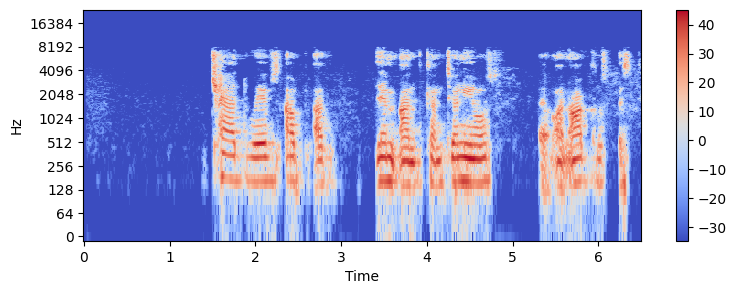

In [13]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

def get_spectrogram(path, sampling_rate = 48000, display = True):
    # Load an audio file as a floating point time series.
    audio , _ = librosa.load(path, sr=sampling_rate)

    # Short-time Fourier transform (STFT).
    stft = abs(librosa.stft(audio))

    # Convert an amplitude spectrogram to dB-scaled spectrogram.
    spectrogram = librosa.amplitude_to_db(stft)

    if display:
        plt.figure(figsize=(9, 3))
        librosa.display.specshow(spectrogram, sr=sampling_rate, x_axis='time', y_axis='log')
        plt.colorbar()
    return spectrogram


_ = get_spectrogram(join("cv_corpus_v1", "wav-files", "cv-invalid", "sample-000020.wav"))

<br>
Feature Extraction:

* gender
* spectral_centroid computes the "average" frequency at each frame, where frequencies are weighted relatively by their energy.
* spectral_bandwidth similar to centroid, but for variance (or other moments).
* spectral_rolloff essentially the maximum: finds the frequency f such that almost all of the energy (for example 95%) in the frame is at frequencies below f. If you set the roll-off to a small fraction (say, 10%), this would give you an estimate of the effective minimum frequency.
* The Mel frequency cepstral coefficients (MFCCs) of a signal are a small set of features (usually 20) which concisely describe the overall shape of a spectral envelope. It models the characteristics of the human voice.


In [14]:
import sklearn

def feature_extraction(path, sampling_rate = 48000):
    features = list()
    audio, _ = librosa.load(path, sr=sampling_rate)

    gender = get_gender(df, path)
    spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sampling_rate))
    spectral_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sampling_rate))
    spectral_rolloff = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sampling_rate))
    features.append(gender)
    features.append(spectral_centroid)
    features.append(spectral_bandwidth)
    features.append(spectral_rolloff)

    mfcc = librosa.feature.mfcc(y=audio, sr=sampling_rate)
    for el in mfcc:
        features.append(np.mean(el))

    return np.asarray(features, dtype=float)


features = feature_extraction(join("cv_corpus_v1", "wav-files", "cv-invalid", "sample-000020.wav"))
print("features: ", features)
print("shape: ", features.shape)

features:  [ 0.00000000e+00  2.22353422e+03  2.28703120e+03  3.55965676e+03
 -4.03133118e+02  1.13350639e+02  3.40530777e+00  9.09154034e+00
 -7.72435808e+00 -6.07953644e+00  1.51617460e+01 -1.58908205e+01
 -1.57723837e+01  5.33236361e+00 -1.23642817e+01 -7.47554016e+00
  2.51936173e+00 -1.05501442e+01 -2.48535943e+00 -1.17643142e+00
 -1.27807856e+01 -2.58007121e+00  2.32499748e-01 -5.17531919e+00]
shape:  (24,)


<br>
Extract features and save them in new csv files.

In [28]:
import csv
import os

# Function to generate the path to the wav file based on the provided filename
def get_wav_name(path):
    info = path.split("/")  # Split the filename by "/"
    filename = os.path.join("cv_corpus_v1", "wav-files", info[0], "{}.wav".format(info[1][:-4]))
    return filename

# Function to parse a row and return the features and label
def parse(row):
    features = feature_extraction(get_wav_name(row["filename"]))  # Feature extraction from wav file
    label = row["age"]
    return [features, label]

# Function to create the header for the CSV file
def create_header():
    header = 'filename gender spectral_centroid spectral_bandwidth spectral_rolloff'
    for i in range(1, 21):
        header += ' mfcc{}'.format(i)
    header += ' label'
    header = header.split()
    return header

# Function to create the CSV files for features
def create_feature_csv(csv_name, header):
    # Ensure the 'feature-csv' directory exists
    feature_csv_dir = os.path.join("cv_corpus_v1", "feature-csv")
    os.makedirs(feature_csv_dir, exist_ok=True)  # Create the directory if it doesn't exist

    # Load the CSV file into a dataframe
    df = get_dataframe(os.path.join("cv_corpus_v1", csv_name))

    # Open the CSV file to write the features
    with open(os.path.join(feature_csv_dir, csv_name), 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(header)  # Write the header

    # Iterate through each row of the dataframe
    for index, row in df.iterrows():
        try:
            # List to store the data to append
            to_append = []

            # Extract the filename and features
            filename = row["filename"]
            features = feature_extraction(get_wav_name(row["filename"]))
            label = row["age"]

            # Append the extracted data
            to_append.append(filename)
            to_append.extend(features)
            to_append.append(label)

            # Append the data to the CSV file
            with open(os.path.join(feature_csv_dir, csv_name), 'a', newline='') as file:
                writer = csv.writer(file)
                writer.writerow(to_append)

        except Exception as e:
            print(f"Error processing file {row['filename']}: {e}")

# Create the header
header = create_header()

# List of CSV files to process
dirs = ["cv-invalid.csv"]

# Process each CSV file and generate the feature CSVs
for el in dirs:
    create_feature_csv(el, header)


<ipython-input-14-da45dd22e6c4>:5: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(path, sr=sampling_rate)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error processing file cv-invalid/sample-000006.mp3: [Errno 2] No such file or directory: 'cv_corpus_v1/wav-files/cv-invalid/sample-000006.wav'
Error processing file cv-invalid/sample-000010.mp3: [Errno 2] No such file or directory: 'cv_corpus_v1/wav-files/cv-invalid/sample-000010.wav'
Error processing file cv-invalid/sample-000019.mp3: [Errno 2] No such file or directory: 'cv_corpus_v1/wav-files/cv-invalid/sample-000019.wav'
Error processing file cv-invalid/sample-000024.mp3: [Errno 2] No such file or directory: 'cv_corpus_v1/wav-files/cv-invalid/sample-000024.wav'
Error processing file cv-invalid/sample-000031.mp3: [Errno 2] No such file or directory: 'cv_corpus_v1/wav-files/cv-invalid/sample-000031.wav'
Error processing file cv-invalid/sample-000033.mp3: [Errno 2] No such file or directory: 'cv_corpus_v1/wav-files/cv-invalid/sample-000033.wav'
Error processing file cv-invalid/sample-000036.mp3: [Errno 2] No such file or directory: 'cv_corpus_v1/wav-files/cv-invalid/sample-000036.wav'

<br>
Join usabel data.

In [29]:
data = pd.concat([pd.read_csv(join("cv_corpus_v1", "feature-csv", "cv-valid-train.csv")), \
                  pd.read_csv(join("cv_corpus_v1", "feature-csv", "cv-invalid.csv")), \
                  pd.read_csv(join("cv_corpus_v1", "feature-csv", "cv-valid-test.csv")), \
                  pd.read_csv(join("cv_corpus_v1", "feature-csv", "cv-valid-dev.csv")), \
                  pd.read_csv(join("cv_corpus_v1", "feature-csv", "cv-other-train.csv")), \
                  pd.read_csv(join("cv_corpus_v1", "feature-csv", "cv-other-test.csv")), \
                  pd.read_csv(join("cv_corpus_v1", "feature-csv", "cv-other-dev.csv"))])
print(data.shape)
data.head()

(1715, 26)


<ipython-input-29-cc6ed3787697>:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([pd.read_csv(join("cv_corpus_v1", "feature-csv", "cv-valid-train.csv")), \


,filename,gender,spectral_centroid,spectral_bandwidth,spectral_rolloff,mfcc1,mfcc2,mfcc3,mfcc4,mfcc5,...,mfcc12,mfcc13,mfcc14,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,mfcc20,label
0,cv-invalid/sample-000001.mp3,0.0,2368.929519,2299.926331,4394.223598,-391.914368,110.983231,0.009770,35.390678,15.752634,...,-1.069324,-6.176723,-6.186791,-2.391511,-3.276588,-5.788778,-2.611023,-2.307450,-4.900065,twenties
1,cv-invalid/sample-000002.mp3,0.0,2127.659179,1988.079070,3710.431985,-513.706726,88.602676,8.255136,-1.924488,5.369352,...,-4.226660,-7.613409,-14.956310,-5.208736,1.932652,1.767889,-0.773345,-7.721047,-3.527942,thirties
2,cv-invalid/sample-000014.mp3,0.0,2202.731121,2597.806865,4181.286197,-485.926392,136.904205,-7.723435,7.649384,21.451866,...,-3.299567,-10.990677,-10.757093,-5.436625,-3.721220,-5.270834,2.550547,1.257155,-9.541892,thirties
3,cv-invalid/sample-000061.mp3,0.0,3792.676515,3002.784004,6694.505129,-347.610657,115.309006,-48.793198,23.851025,-3.401801,...,-12.858023,2.843994,-8.404846,-9.303495,-6.184469,-2.084787,-3.390183,-4.587194,-5.855249,teens
4,cv-invalid/sample-000081.mp3,0.0,7983.697575,6575.345537,16830.750778,-1075.252686,23.236332,-16.307268,6.902150,0.968312,...,1.233762,-0.570644,0.856187,0.467472,0.166105,0.914284,0.236405,0.830423,0.416343,twenties


<br>
Encoding the labels.

In [30]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

def get_labels(data):
    labels = data.iloc[:, -1]
    encoder = LabelEncoder()
    labels = encoder.fit_transform(labels)
    return labels, encoder

y, encoder = get_labels(data)
labels = encoder.classes_
print("labels: ", labels)

labels:  ['eighties' 'fifties' 'fourties' 'seventies' 'sixties' 'teens' 'thirties'
 'twenties']


<br>
Scaling the features.

In [31]:
def scale_features(data):
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(np.array(data.iloc[:, 1:-1], dtype = float))
    # with data.iloc[:, 1:-1] we don't consider filename and label

    # in this way, gender will be always -1, 0 or +1 and so it won't be scaled
    for i in range(len(scaled_data)):
        scaled_data[i][0] = data.iloc[i, 1]

    return scaled_data, scaler

x, scaler = scale_features(data)

<br>
Split data in Training, Test and Validation set.

* Training set:    80 %
* Test set:        10 %
* Validation set:  10 %

In [39]:
# balanced split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0, stratify=y)
x_test, x_val, y_test, y_val = train_test_split(x_test, y_test, test_size=0.5, random_state=0)

print("x_train: ", x_train.shape)
print("x_test: ", x_test.shape)
print("x_val: ", x_val.shape)

x_train:  (1372, 24)
x_test:  (171, 24)
x_val:  (172, 24)


<br>

## Classification

In [40]:
from keras import models
from keras import layers

model = models.Sequential()
model.add(layers.BatchNormalization(input_shape=(x_train.shape[1],)))
model.add(layers.Dense(1024, activation='relu'))

model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))
model.add(layers.Dense(1024, activation='relu'))

model.add(layers.BatchNormalization())
model.add(layers.Dense(1024, activation='relu'))

model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))
model.add(layers.Dense(1024, activation='relu'))

model.add(layers.BatchNormalization())
model.add(layers.Dense(1024, activation='relu'))

model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))
model.add(layers.Dense(1024, activation='relu'))

model.add(layers.BatchNormalization())
model.add(layers.Dense(1024, activation='relu'))

model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))
model.add(layers.Dense(1024, activation='relu'))

model.add(layers.BatchNormalization())
model.add(layers.Dense(8, activation='softmax'))    # note that 8 is the number of possible labels

/usr/local/lib/python3.11/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [41]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ batch_normalization_9                │ (None, 24)                  │              96 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1024)                │          25,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1024)                │       1,049,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1024)                │       1,049,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1024)                │       1,049,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1024)                │       1,049,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1024)                │       1,049,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1024)                │       1,049,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 1024)                │           4,0

 Total params: 7,413,864 (28.28 MB)

 Trainable params: 7,397,432 (28.22 MB)

 Non-trainable params: 16,432 (64.19 KB)

None


In [44]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

# Update the filepath to end with `.keras`
checkpointer = ModelCheckpoint(filepath='best_model.keras',
                               verbose=1, save_best_only=True)

early_stopping = EarlyStopping(monitor='val_loss', min_delta=0, patience=3, verbose=1, mode='auto')


### First stage of training

In [45]:
epochs = 50
batch_size = 128
history = model.fit(x_train,
                    y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    callbacks=[checkpointer, early_stopping],
                    validation_data=(x_val, y_val))

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.2017 - loss: 2.8388
Epoch 1: val_loss improved from inf to 1.95459, saving model to best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 219ms/step - accuracy: 0.2057 - loss: 2.8388 - val_accuracy: 0.3547 - val_loss: 1.9546
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.4182 - loss: 2.1782
Epoch 2: val_loss improved from 1.95459 to 1.93009, saving model to best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step - accuracy: 0.4178 - loss: 2.1790 - val_accuracy: 0.3547 - val_loss: 1.9301
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5089 - loss: 1.6136
Epoch 3: val_loss improved from 1.93009 to 1.83149, saving model to best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 222ms/step - accuracy: 0.5084 - loss: 1.6168 - val_accuracy: 0.4012 - val_loss: 1.8315
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5761 - loss: 1.2921
Epoch 4: val_loss improved from 1.83149 to 1.79558, sa

In [47]:
model.load_weights('best_model.keras')
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy: {0:.2f} %".format(test_acc*100))


Test accuracy: 34.50 %


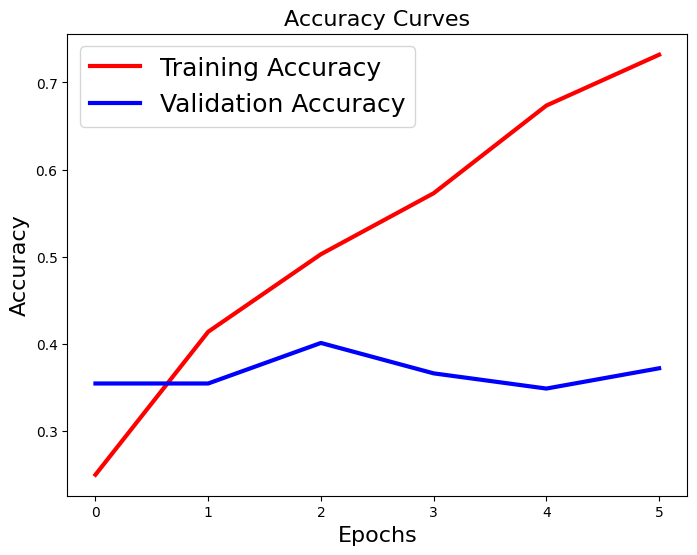

In [49]:
last_good_epoch = early_stopping.stopped_epoch - early_stopping.patience + 1

# Accuracy Curves
plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'][:last_good_epoch], 'r', linewidth=3.0)
plt.plot(history.history['val_accuracy'][:last_good_epoch], 'b', linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'], fontsize=18)
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.title('Accuracy Curves', fontsize=16)
plt.show()


Text(0.5, 1.0, 'Loss Curves')

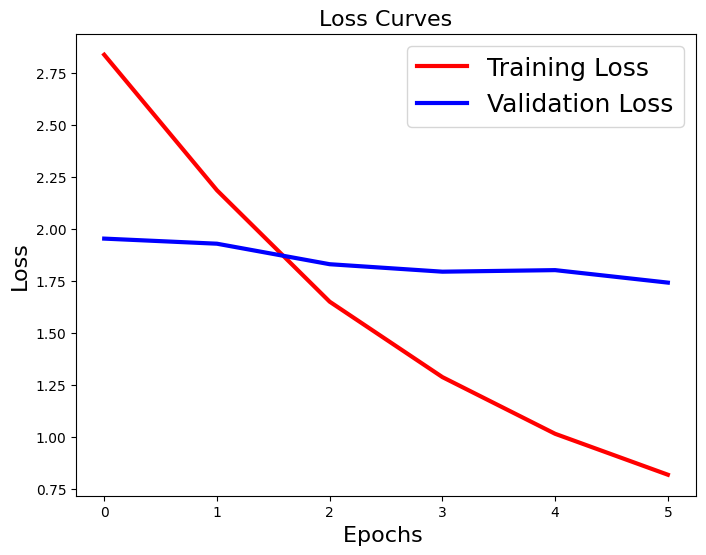

In [50]:
# Loss Curves
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'][:last_good_epoch],'r',linewidth=3.0)
plt.plot(history.history['val_loss'][:last_good_epoch],'b',linewidth=3.0)
plt.legend(['Training Loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

### Second stage of training

In [51]:
epochs = 50
batch_size = 256
history2 = model.fit(x_train,
                    y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    callbacks=[checkpointer, early_stopping],
                    validation_data=(x_val, y_val))

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.8082 - loss: 0.6395
Epoch 1: val_loss did not improve from 1.74302
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.8074 - loss: 0.6377 - val_accuracy: 0.3779 - val_loss: 1.7927
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.8398 - loss: 0.5319
Epoch 2: val_loss did not improve from 1.74302
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step - accuracy: 0.8379 - loss: 0.5332 - val_accuracy: 0.3547 - val_loss: 1.8451
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.8825 - loss: 0.3891
Epoch 3: val_loss did not improve from 1.74302
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.8826 - loss: 0.3895 - val_accuracy: 0.3430 - val_loss: 1.8404
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.8784 - loss: 0.4084
Epoch 4: val_loss did not improve from 1.74302
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 208ms/step - accuracy: 0.8786 - loss: 0.4041 - val_accuracy: 0.3488 - val_loss: 2.2051
Epoch 4: early s

In [53]:
model.load_weights('best_model.keras')
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy: {0:.2f} %".format(test_acc*100))

Test accuracy: 34.50 %


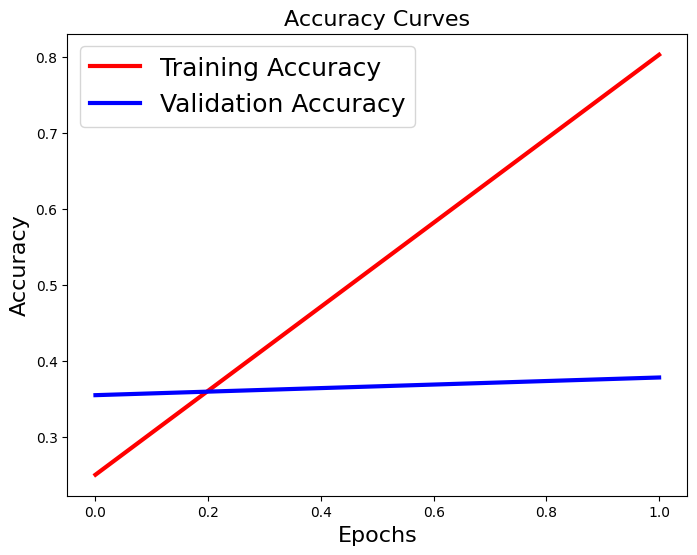

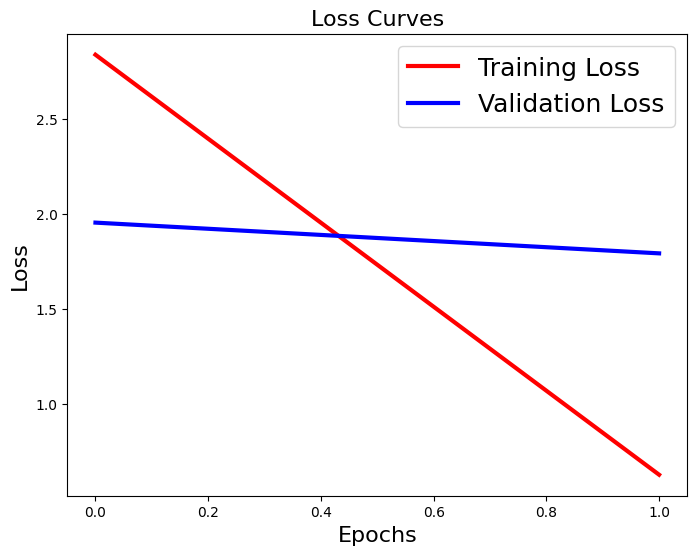

In [56]:
# Adjusted to use 'accuracy' and 'val_accuracy' keys
last_good_epoch = early_stopping.stopped_epoch - early_stopping.patience + 1
last_good_epoch2 = early_stopping.stopped_epoch - early_stopping.patience + 1

# Combine the accuracies from both histories
acc_to_plot = history.history['accuracy'][:last_good_epoch] + history2.history['accuracy'][:last_good_epoch2]
val_acc_to_plot = history.history['val_accuracy'][:last_good_epoch] + history2.history['val_accuracy'][:last_good_epoch2]

# Plotting Accuracy Curves
plt.figure(figsize=[8,6])
plt.plot(acc_to_plot, 'r', linewidth=3.0)
plt.plot(val_acc_to_plot, 'b', linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'], fontsize=18)
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.title('Accuracy Curves', fontsize=16)
plt.show()

# Combine the losses from both histories
loss_to_plot = history.history['loss'][:last_good_epoch] + history2.history['loss'][:last_good_epoch2]
val_loss_to_plot = history.history['val_loss'][:last_good_epoch] + history2.history['val_loss'][:last_good_epoch2]

# Plotting Loss Curves
plt.figure(figsize=[8,6])
plt.plot(loss_to_plot, 'r', linewidth=3.0)
plt.plot(val_loss_to_plot, 'b', linewidth=3.0)
plt.legend(['Training Loss', 'Validation Loss'], fontsize=18)
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.title('Loss Curves', fontsize=16)
plt.show()


### Third stage of training

In [57]:
epochs = 50
batch_size = 512
history3 = model.fit(x_train,
                    y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    callbacks=[checkpointer, early_stopping],
                    validation_data=(x_val, y_val))

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.8033 - loss: 0.6256
Epoch 1: val_loss did not improve from 1.74302
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 397ms/step - accuracy: 0.8060 - loss: 0.6186 - val_accuracy: 0.3663 - val_loss: 1.7638
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.8304 - loss: 0.5967
Epoch 2: val_loss did not improve from 1.74302
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 372ms/step - accuracy: 0.8318 - loss: 0.5903 - val_accuracy: 0.3779 - val_loss: 1.7716
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.8396 - loss: 0.5260
Epoch 3: val_loss did not improve from 1.74302
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 363ms/step - accuracy: 0.8414 - loss: 0.5196 - val_accuracy: 0.3779 - val_loss: 1.7849
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.8858 - loss: 0.3604
Epoch 4: val_loss did not improve from 1.74302
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 416ms/step - accuracy: 0.8841 - loss: 0.3650 - val_accuracy: 0.3895 - val_loss: 1.8138
Epoch 4: early s

In [58]:
model.load_weights('best_model.keras')
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy: {0:.2f} %".format(test_acc*100))

Test accuracy: 34.50 %


Text(0.5,1,'Loss Curves')

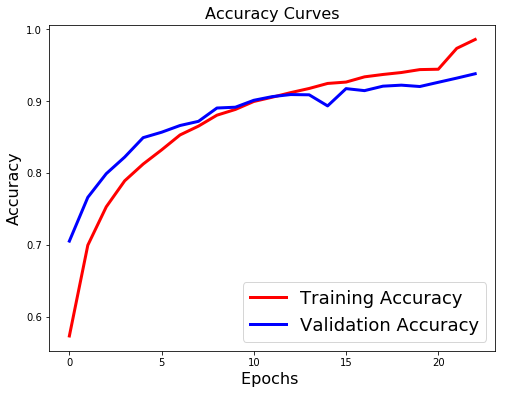

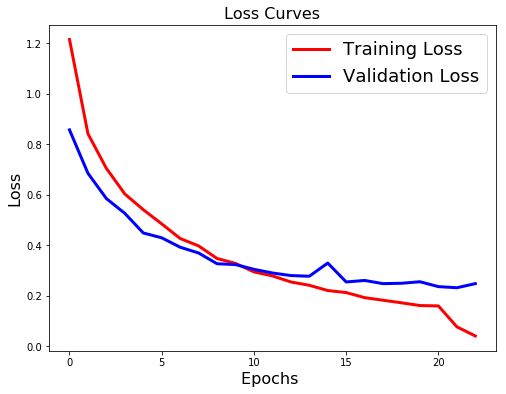

In [ ]:
last_good_epoch3 = early_stopping.stopped_epoch - early_stopping.patience + 1

acc_to_plot += history3.history['acc'][:last_good_epoch3]
val_acc_to_plot += history3.history['val_acc'][:last_good_epoch3]

plt.figure(figsize=[8,6])
plt.plot(acc_to_plot,'r',linewidth=3.0)
plt.plot(val_acc_to_plot,'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

loss_to_plot += history3.history['loss'][:last_good_epoch3]
val_loss_to_plot += history3.history['val_loss'][:last_good_epoch3]

plt.figure(figsize=[8,6])
plt.plot(loss_to_plot,'r',linewidth=3.0)
plt.plot(val_loss_to_plot,'b',linewidth=3.0)
plt.legend(['Training Loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

### Fourth stage of training

In [ ]:
epochs = 50
batch_size = 1024
history4 = model.fit(x_train,
                    y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    callbacks=[checkpointer, early_stopping],
                    validation_data=(x_val, y_val))

Train on 114536 samples, validate on 14317 samples
Epoch 1/50
114536/114536 [==============================] - 19s 168us/step - loss: 0.0342 - acc: 0.9880 - val_loss: 0.2386 - val_acc: 0.9394

Epoch 00001: val_loss did not improve from 0.23196
Epoch 2/50
114536/114536 [==============================] - 19s 167us/step - loss: 0.0238 - acc: 0.9916 - val_loss: 0.2560 - val_acc: 0.9394

Epoch 00002: val_loss did not improve from 0.23196
Epoch 3/50
114536/114536 [==============================] - 19s 169us/step - loss: 0.0201 - acc: 0.9931 - val_loss: 0.2602 - val_acc: 0.9408

Epoch 00003: val_loss did not improve from 0.23196
Epoch 4/50
114536/114536 [==============================] - 19s 167us/step - loss: 0.0190 - acc: 0.9935 - val_loss: 0.2700 - val_acc: 0.9406

Epoch 00004: val_loss did not improve from 0.23196
Epoch 00004: early stopping


In [ ]:
model.load_weights('best_model.hdf5')
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy: {0:.2f} %".format(test_acc*100))

Test accuracy: 93.27 %


Text(0.5,1,'Loss Curves')

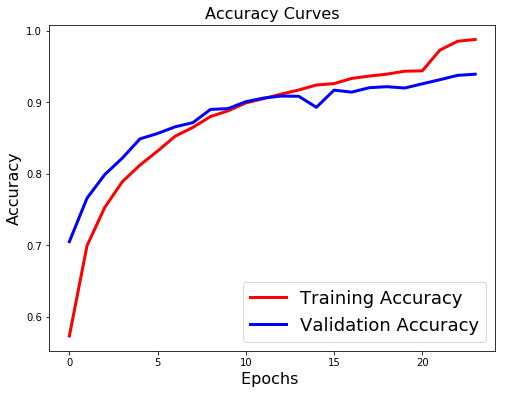

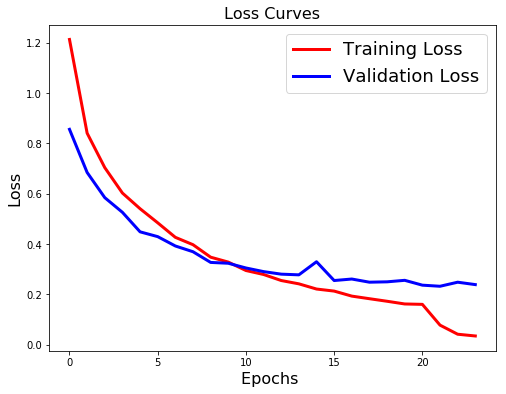

In [ ]:
last_good_epoch4 = early_stopping.stopped_epoch - early_stopping.patience + 1

acc_to_plot += history4.history['acc'][:last_good_epoch4]
val_acc_to_plot += history4.history['val_acc'][:last_good_epoch4]

plt.figure(figsize=[8,6])
plt.plot(acc_to_plot,'r',linewidth=3.0)
plt.plot(val_acc_to_plot,'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)


loss_to_plot += history4.history['loss'][:last_good_epoch4]
val_loss_to_plot += history4.history['val_loss'][:last_good_epoch4]

plt.figure(figsize=[8,6])
plt.plot(loss_to_plot,'r',linewidth=3.0)
plt.plot(val_loss_to_plot,'b',linewidth=3.0)
plt.legend(['Training Loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

### Fifth stage of training

In [ ]:
epochs = 50
batch_size = 2048
history5 = model.fit(x_train,
                    y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    callbacks=[checkpointer, early_stopping],
                    validation_data=(x_val, y_val))

Train on 114536 samples, validate on 14317 samples
Epoch 1/50
114536/114536 [==============================] - 15s 135us/step - loss: 0.0326 - acc: 0.9893 - val_loss: 0.2416 - val_acc: 0.9400

Epoch 00001: val_loss did not improve from 0.23196
Epoch 2/50
114536/114536 [==============================] - 16s 136us/step - loss: 0.0216 - acc: 0.9926 - val_loss: 0.2540 - val_acc: 0.9394

Epoch 00002: val_loss did not improve from 0.23196
Epoch 3/50
114536/114536 [==============================] - 15s 135us/step - loss: 0.0181 - acc: 0.9938 - val_loss: 0.2653 - val_acc: 0.9414

Epoch 00003: val_loss did not improve from 0.23196
Epoch 4/50
114536/114536 [==============================] - 15s 134us/step - loss: 0.0153 - acc: 0.9946 - val_loss: 0.2725 - val_acc: 0.9392

Epoch 00004: val_loss did not improve from 0.23196
Epoch 00004: early stopping


In [ ]:
model.load_weights('best_model.hdf5')
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy: {0:.2f} %".format(test_acc*100))

Test accuracy: 93.27 %


Text(0.5,1,'Loss Curves')

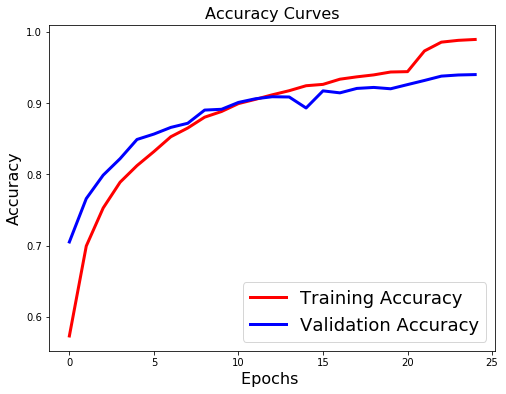

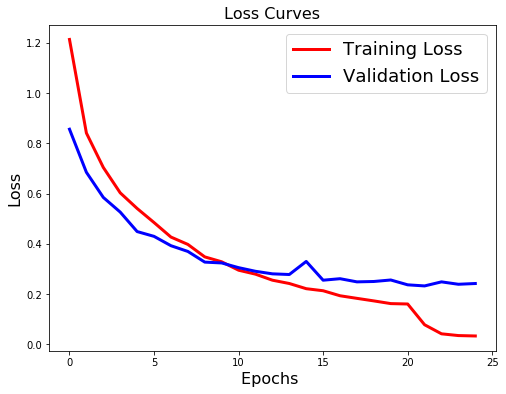

In [ ]:
last_good_epoch5 = early_stopping.stopped_epoch - early_stopping.patience + 1

acc_to_plot += history5.history['acc'][:last_good_epoch5]
val_acc_to_plot += history5.history['val_acc'][:last_good_epoch5]

plt.figure(figsize=[8,6])
plt.plot(acc_to_plot,'r',linewidth=3.0)
plt.plot(val_acc_to_plot,'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)


loss_to_plot += history5.history['loss'][:last_good_epoch5]
val_loss_to_plot += history5.history['val_loss'][:last_good_epoch5]

plt.figure(figsize=[8,6])
plt.plot(loss_to_plot,'r',linewidth=3.0)
plt.plot(val_loss_to_plot,'b',linewidth=3.0)
plt.legend(['Training Loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

<br>
Save model and scaler.

In [63]:
import os
import joblib

# Ensure the directory exists
os.makedirs("last_models", exist_ok=True)

# Save your model and scaler
model.save("last_models/network.keras")  # Use .keras or .h5 extension
joblib.dump(scaler, "last_models/scaler")


['last_models/scaler']

<br>
Examples of prediction.

In [64]:
df = get_dataframe(join("cv_corpus_v1", "cv-valid-test.csv"))
df.head(10)

,filename,text,up_votes,down_votes,age,gender,accent,duration
1,cv-valid-test/sample-000001.mp3,i've got to go to him,1,0,twenties,male,NaN,NaN
3,cv-valid-test/sample-000003.mp3,down below in the darkness were hundreds of pe...,4,0,twenties,male,us,NaN
5,cv-valid-test/sample-000005.mp3,down below in the darkness were hundreds of pe...,4,1,twenties,male,us,NaN
6,cv-valid-test/sample-000006.mp3,strange images passed through my mind,3,0,twenties,male,NaN,NaN
7,cv-valid-test/sample-000007.mp3,the sheep had taught him that,2,0,thirties,male,NaN,NaN
8,cv-valid-test/sample-000008.mp3,this was the strangest of all things that ever...,1,0,thirties,male,england,NaN
9,cv-valid-test/sample-000009.mp3,it was glaringly hot not a cloud in the sky no...,3,0,fifties,male,us,NaN
11,cv-valid-test/sample-000011.mp3,they made the boy continue digging but he foun...,2,0,twenties,male,NaN,NaN
14,cv-valid-test/sample-000014.mp3,follow the instructions here,1,0,twenties,male,scotland,NaN
16,cv-valid-test/sample-000016.mp3,the shop is closed on mondays,1,0,twenties,male,NaN,NaN


Files in 'best_model' directory: ['network.keras', 'scaler']


True age:       23
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
Predicted age:  twenties


Text(0.5, 1.0, 'Loss Curves')

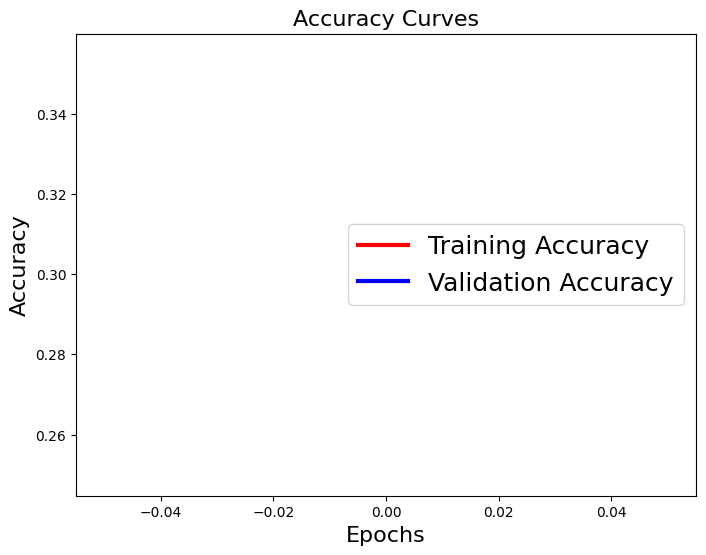

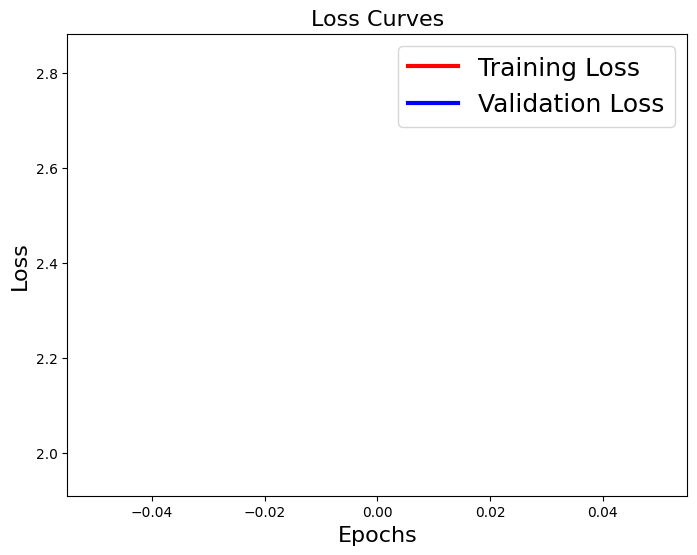

In [76]:
import os
import numpy as np
from keras import models
import joblib
import matplotlib.pyplot as plt

def test_prediction(df, model, scaler, path):
    features = feature_extraction(path)
    gender = features[0]
    features = scaler.transform(features.reshape(1, -1))  # Reshape as a single sample
    features = features[0]  # Convert shape from (1, 24) to (24,)
    features[0] = gender  # Ensure gender is the first feature

    print("True age:      ", get_age(df, path))
    prediction = model.predict(np.expand_dims(features, axis=0))
    print("Predicted age: ", labels[np.argmax(prediction)])

# Ensure directory exists for saving the model
if not os.path.exists("best_model"):
    os.makedirs("best_model")

# Save model and scaler
model.save("best_model/network.keras")  # Save model with `.keras` extension
joblib.dump(scaler, "best_model/scaler")  # Save scaler

# Check if the model and scaler files are saved properly
print("Files in 'best_model' directory:", os.listdir("best_model"))

# Load model and scaler
model = models.load_model("best_model/network.keras")  # Load with correct `.keras` extension
scaler = joblib.load("best_model/scaler")  # Load the scaler

# Define a path to the sound file (example)
path = os.path.join("cv_corpus_v1", "wav-files", "cv-invalid", "sample-000001.wav")
play_sound(path)

# Assuming df is already defined and you have the features for testing
test_prediction(df, model, scaler, path)

# Accuracy and loss plot (if needed)
last_good_epoch = early_stopping.stopped_epoch - early_stopping.patience + 1

plt.figure(figsize=[8, 6])
plt.plot(history.history['accuracy'][:last_good_epoch], 'r', linewidth=3.0)
plt.plot(history.history['val_accuracy'][:last_good_epoch], 'b', linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'], fontsize=18)
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.title('Accuracy Curves', fontsize=16)

loss_to_plot = history.history['loss'][:last_good_epoch]
val_loss_to_plot = history.history['val_loss'][:last_good_epoch]

plt.figure(figsize=[8, 6])
plt.plot(loss_to_plot, 'r', linewidth=3.0)
plt.plot(val_loss_to_plot, 'b', linewidth=3.0)
plt.legend(['Training Loss', 'Validation Loss'], fontsize=18)
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.title('Loss Curves', fontsize=16)


In [80]:
path = join("cv_corpus_v1", "wav-files", "cv-invalid", "sample-000015.wav")
play_sound(path)
test_prediction(df, model, scaler, path)

True age:       20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predicted age:  twenties


<br>
Confusion matrix.

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step


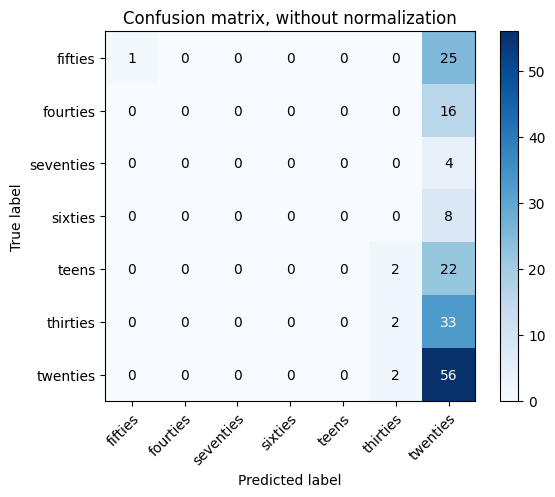

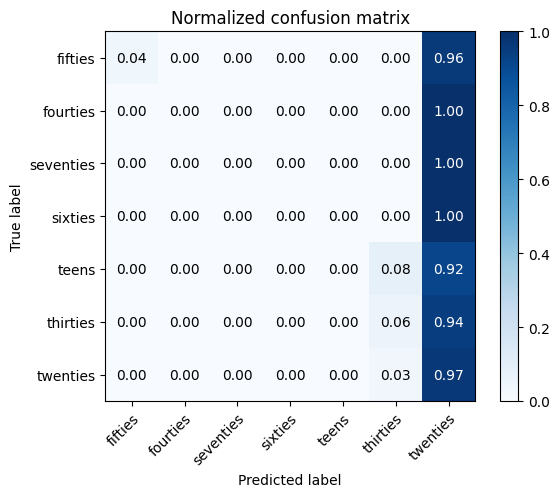

In [82]:
import os
import numpy as np
from keras import models
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels
import matplotlib.pyplot as plt

# Define function to plot confusion matrix
def plot_confusion_matrix(y_test, y_pred, classes, normalize=False, title=None, cmap=plt.cm.Blues):
    cm = confusion_matrix(y_test, y_pred)  # Compute confusion matrix

    # Only use the labels that appear in the data
    classes = [classes[el] for el in unique_labels(y_test, y_pred)]

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),  # We want to show all ticks...
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes,  # Label them with the respective list entries
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    return ax

# Load the saved model in `.keras` format (or `.h5`)
model_path = "best_model/network.keras"  # Ensure you're saving and loading the model with this extension
if not os.path.exists(model_path):
    print(f"Model file {model_path} does not exist. Ensure you've saved the model correctly.")

model = models.load_model(model_path)

# Assuming x_test and y_test are already defined for predictions
y_pred = model.predict(x_test)
y_pred = np.asarray([np.argmax(el) for el in y_pred])  # Convert predictions to class indices

np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plot_confusion_matrix(y_test, y_pred, classes=labels, title='Confusion matrix, without normalization')

# Plot normalized confusion matrix
plot_confusion_matrix(y_test, y_pred, classes=labels, normalize=True, title='Normalized confusion matrix')

plt.show()


<br>
Trying with my voice.

In [87]:
import librosa
import joblib
import numpy as np
from tensorflow.keras import models

# Define labels and gender dictionary
labels = ['eighties', 'fifties', 'fourties', 'seventies', 'sixties', 'teens', 'thirties', 'twenties']
gender_dict = {"male": -1, "female": +1, "other": 0}

# Feature extraction function for the voice audio file
def app_feature_extraction(path, gender, sampling_rate=48000):
    features = list()
    audio, _ = librosa.load(path, sr=sampling_rate)

    # Extracting spectral features
    spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sampling_rate))
    spectral_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sampling_rate))
    spectral_rolloff = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sampling_rate))
    features.append(gender)
    features.append(spectral_centroid)
    features.append(spectral_bandwidth)
    features.append(spectral_rolloff)

    # Extracting MFCC features
    mfcc = librosa.feature.mfcc(y=audio, sr=sampling_rate)
    for el in mfcc:
        features.append(np.mean(el))

    return np.asarray(features, dtype=float)

# Prediction function using the pre-trained model
def my_voice_prediction(path, gender, model, scaler, test_number):
    features = app_feature_extraction(path, gender)
    gender = features[0]
    features = scaler.transform(features.reshape(1, -1))  # Reshape to a single sample
    features = features[0]   # Shape is (1, 24), but we want (24,)
    features[0] = gender     # Set gender as +1, 0, or -1
    prediction = model.predict(np.expand_dims(features, axis=0))
    print("predicted age of test{}: {}".format(test_number, labels[np.argmax(prediction)]))

# Load the model and scaler
gender = gender_dict["male"]
model = models.load_model("best_model/network.h5")  # Load the model in .h5 format
scaler = joblib.load("best_model/scaler")  # Load the pre-trained scaler

# Perform predictions for each test audio file
# print("True age: 24")
# my_voice_prediction("audio_tests/test1.wav", gender, model, scaler, test_number=1)
# my_voice_prediction("audio_tests/test2.wav", gender, model, scaler, test_number=2)
# my_voice_prediction("audio_tests/test3.wav", gender, model, scaler, test_number=3)
# my_voice_prediction("audio_tests/test4.wav", gender, model, scaler, test_number=4)
# my_voice_prediction("audio_tests/test5.wav", gender, model, scaler, test_number=5)
# my_voice_prediction("audio_tests/test6.wav", gender, model, scaler, test_number=6)
# my_voice_prediction("audio_tests/test7.wav", gender, model, scaler, test_number=7)
# my_voice_prediction("audio_tests/test8.wav", gender, model, scaler, test_number=8)
# my_voice_prediction("audio_tests/test9.wav", gender, model, scaler, test_number=9)
# my_voice_prediction("audio_tests/test10.wav", gender, model, scaler, test_number=10)
